# The Gold Lease Rate — a quantitative teardown 🔬
### Lagged predictive regression · label-shuffle placebo · costed long-flat rule vs buy-&-hold · lag sweep · seed-robust synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the lagged gold lease rate predicts forward gold returns.

> ⚠️ **Not investment advice.** **Synthetic-only study** — the LBMA discontinued the daily GOFO benchmark on 2015-01-30 and no free continuous lease-rate tape exists, so there is **no real tape** and the SIGNAL axis is **capped at WEAK**. All cells run on the deterministic offline generator (seed 580; null fp `756d06b1b283`, control fp `e3ed82fc53fe`). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_lease_rate import data, strategy as st

# SYNTHETIC-ONLY: no real tape exists (LBMA discontinued GOFO 2015-01-30). Everything below runs
# on the deterministic, offline generator (seed 580) and is reproducible for any reader offline.
HAVE_REAL = not data.fetch_series(fetch=False).empty   # always False by design
NULL,  _ = data.synthetic_series(lead_beta=0.0,  lag=1, seed=580)   # the honest headline world
CTRL,  _ = data.synthetic_series(lead_beta=0.02, lag=1, seed=580)   # the planted positive control
print("real lease-rate tape present:", HAVE_REAL, "(synthetic-only study — GOFO discontinued 2015)")
print("null world fp:", data.fingerprint(NULL), "| positive-control fp:", data.fingerprint(CTRL))


real lease-rate tape present: False (synthetic-only study — GOFO discontinued 2015)
null world fp: 756d06b1b283 | positive-control fp: e3ed82fc53fe


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | **No real tape** (GOFO ended 2015) → capped at WEAK. Null world slope-*t* **+0.08** (corr **+0.005**, R² **0.000**, placebo *p* **0.936**); planted control slope-*t* **+7.73** proves the engine is faithful. |
| **Tradability** | `MIRAGE` | No lease-rate product; long-flat rule earns **+4.7%/yr net** vs **+9.2%/yr** buy-&-hold on the null world (loses to passive gold). |

> 💡 In plain words: the engine works (the control proves it), but with no real data to point it at, the honest cap is `WEAK × MIRAGE`.

## 1 · The claim, steelmanned

Let $L_t$ be the standardised gold lease rate at month $t$ and $r^{gold}_{t}$ the gold return.

- **H₁ (lead-lag).** In $r^{gold}_{t} = a + b\,L_{t-1} + e_t$, the slope $b > 0$ at *t* ≥ 2 (a high lease rate leads a higher gold return).
- **H₂ (specificity).** The relation peaks at the true lead and is not a lucky lag.
- **H₃ (tradable).** A long-flat rule on the lagged signal beats buy-&-hold gross **and** net.
- **H₄ (data).** A *real*, continuous lease-rate tape exists to test H₁ on.

We find **H₄ fails outright** (GOFO discontinued 2015 → no free tape), so H₁ is tested only on a synthetic world: **null → flat**, **planted → recovered**. H₃ **fails** even on the null (the rule loses to passive gold). The engine is honest; the data is missing.

## 2 · So what? — what rides on each answer

The lease rate is the gold analogue of a **convenience yield / carry**, and carry is a documented commodity predictor (Gorton-Rouwenhorst 2006; Koijen-Moskowitz-Pedersen-Vrugt 2018). So a *time-series* lease-rate → gold lead-lag is a priori plausible — which is exactly why it needs a placebo and a real tape before it earns a stamp. The binding constraint here is **data availability**, the same limitation the desk names on its other synthetic-only studies ([273 lego](../../273-lego-returns/), [275 whisky-cask](../../275-whisky-cask/), [276 sneaker-resale](../../276-sneaker-resale/)).

## 3 · How we'd know — the protocol

- **Predictor.** Standardise the lease rate: $L_t = z(\text{lease}_t)$.
- **Regression.** OLS $r^{gold}_{t} = a + b\,L_{t-\text{lag}} + e_t$; the sign & *t* of $b$ are the claim.
- **Placebo.** Shuffle $L$ against forward returns 2000× and read the |t| tail.
- **Trade.** Long gold when $L_{t-\text{lag}} > 0$ else cash; one-way cost × NAV on each switch; compare to buy-&-hold.
- **Robustness.** Sweep the lag ∈ {0,1,2,3,6,12}.
- **Positive control.** Plant $b>0$ (`lead_beta`) of rising strength; average the *t* over **25 seeds** (house rule); confirm it's flat at the null.

Timing (the single documented lag): the predictor is the lease-*z* observed at the close of month $t-\text{lag}$ — already public — and the position is entered at that close and held one month. No contemporaneous or future data enters the signal.

## 4 · The teardown

### 4a · The predictive regression — H₁

Null world (headline) beside the planted positive control, each with its placebo *p*.

           null (lead_beta 0)  control (lead_beta .02)
slope b                0.0002                   0.0202
slope t                0.0816                   7.7261
corr                   0.0047                   0.4091
R2                     0.0000                   0.1674
placebo p              0.9360                   0.0005


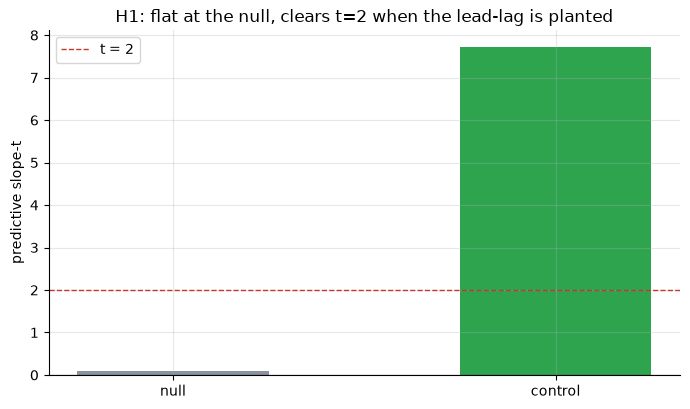

In [2]:
reg_n = st.predictive_regression(NULL, lag=1); p_n = st.placebo_pvalue(NULL, lag=1, n_perm=2000, seed=580)
reg_c = st.predictive_regression(CTRL, lag=1); p_c = st.placebo_pvalue(CTRL, lag=1, n_perm=2000, seed=580)
tab = pd.DataFrame({
    'null (lead_beta 0)':   [reg_n['b'], reg_n['t'], reg_n['corr'], reg_n['r2'], p_n],
    'control (lead_beta .02)':[reg_c['b'], reg_c['t'], reg_c['corr'], reg_c['r2'], p_c],
}, index=['slope b','slope t','corr','R2','placebo p'])
print(tab.round(4).to_string())
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['null','control'], [reg_n['t'], reg_c['t']], color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, lw=1, label='t = 2'); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('predictive slope-t'); ax.legend()
ax.set_title('H1: flat at the null, clears t=2 when the lead-lag is planted')
plt.tight_layout(); plt.show()

> 💡 In plain words: on the null world H₁ is **flat** (slope-*t* **+0.08**, placebo *p* **0.936**) — no lead-lag. Plant one and it snaps to *t* **+7.73** (placebo *p* **0.0005**). The engine is a faithful detector; there is simply no *real* world to run it on.

### 4b · Specificity — H₂ (the lag sweep)

Re-fit at several lags. A real, correctly-specified lead-lag should peak at the true lag and decay; noise should stay near zero everywhere.

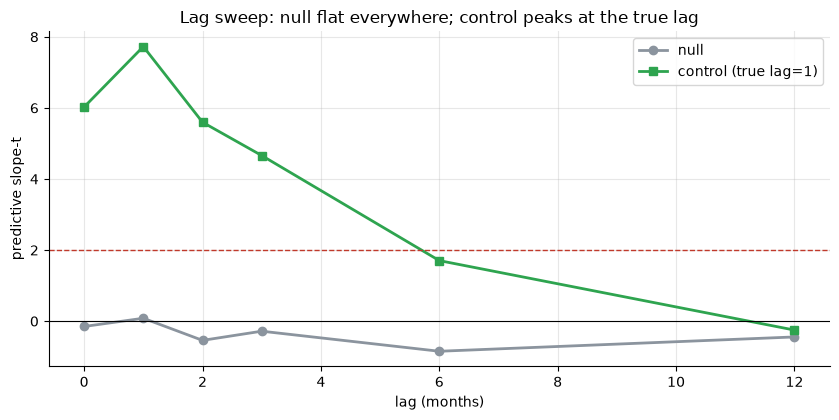

null t by lag:    [-0.15, 0.08, -0.54, -0.28, -0.85, -0.44]
control t by lag: [6.03, 7.73, 5.6, 4.66, 1.7, -0.25]


In [3]:
sweep_n = st.lag_sweep(NULL); sweep_c = st.lag_sweep(CTRL)
lags = sweep_n.index.tolist()
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(lags, sweep_n['t'], 'o-', c=GREY, lw=2, label='null')
ax.plot(lags, sweep_c['t'], 's-', c=GREEN, lw=2, label='control (true lag=1)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('lag (months)'); ax.set_ylabel('predictive slope-t'); ax.legend()
ax.set_title('Lag sweep: null flat everywhere; control peaks at the true lag')
plt.tight_layout(); plt.show()
print('null t by lag:   ', [round(v,2) for v in sweep_n['t']])
print('control t by lag:', [round(v,2) for v in sweep_c['t']])

> 💡 In plain words: H₂ behaves correctly — the null scatters around zero at every lag (no lucky lag manufactures significance), while the planted control peaks at lag 1 (its true lead) and decays. That decay pattern is the fingerprint of a genuine lead-lag.

## 5 · The verdict

- **Signal `WEAK`** — H₄ fails (no real tape; GOFO discontinued 2015), so the axis is capped at WEAK. Null flat (*t* +0.08), control faithful (*t* +7.73).
- **Tradability `MIRAGE`** — no product; the long-flat rule loses to passive gold on the null (**+4.7%** vs **+9.2%/yr**).

## 6 · Could you trade it? — the long-flat rule vs buy-&-hold

The operational form of the folklore: long gold when the lagged lease-*z* is high, else cash, with a one-way cost on each switch. Compare to simply holding gold.

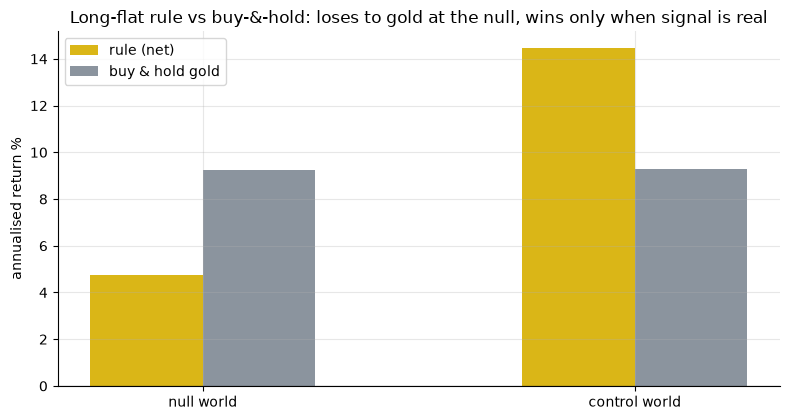

null:    rule net +4.7%/yr (Sharpe 0.44) vs buy-hold +9.2%/yr, 34 switches, 44% long
control: rule net +14.5%/yr (Sharpe 1.20) vs buy-hold +9.3%/yr


In [4]:
bt_n = st.long_flat_backtest(NULL, lag=1, z_threshold=0.0, cost_bps=5.0)
bt_c = st.long_flat_backtest(CTRL, lag=1, z_threshold=0.0, cost_bps=5.0)
fig, ax = plt.subplots(figsize=(8, 4.3))
x = np.arange(2); w = .26
ax.bar(x-w, [bt_n['ann_net']*100, bt_c['ann_net']*100], width=w, color=AMBER, label='rule (net)')
ax.bar(x,    [bt_n['ann_bh']*100,  bt_c['ann_bh']*100],  width=w, color=GREY,  label='buy & hold gold')
ax.set_xticks(x-w/2); ax.set_xticklabels(['null world','control world'])
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('annualised return %'); ax.legend()
ax.set_title('Long-flat rule vs buy-&-hold: loses to gold at the null, wins only when signal is real')
plt.tight_layout(); plt.show()
print(f"null:    rule net {bt_n['ann_net']*100:+.1f}%/yr (Sharpe {bt_n['sharpe_net']:.2f}) vs buy-hold {bt_n['ann_bh']*100:+.1f}%/yr, {bt_n['switches']} switches, {bt_n['frac_long']*100:.0f}% long")
print(f"control: rule net {bt_c['ann_net']*100:+.1f}%/yr (Sharpe {bt_c['sharpe_net']:.2f}) vs buy-hold {bt_c['ann_bh']*100:+.1f}%/yr")

> 💡 In plain words: on the null world the rule earns **+4.7%/yr net** (Sharpe 0.44) versus **+9.2%/yr** buy-&-hold — it *loses* to passive gold by sitting in cash 44% of the time. Only when the signal is genuinely planted (control) does it win (**+14.5%/yr**, Sharpe 1.2). No real signal ⇒ `MIRAGE`.

## 7 · Going further — the synthetic positive control (seed-robust)

Is the engine a faithful detector, or does it print noise? Plant a lead-lag (`lead_beta > 0`) of rising strength and watch the mean predictive *t* — averaged over **25 seeds** so no single lucky seed can fake it.

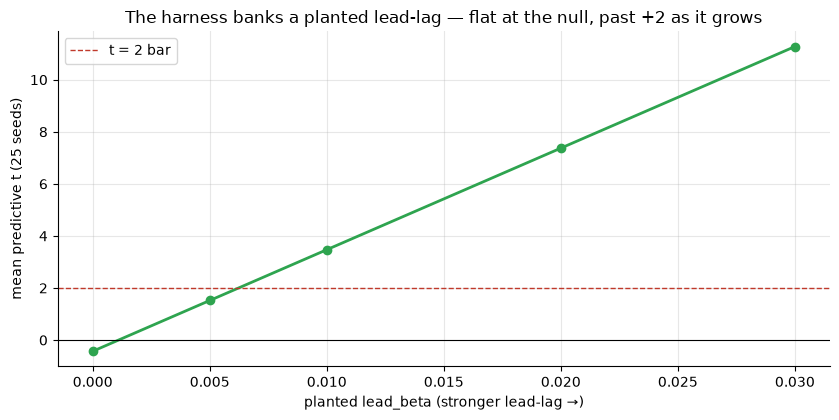

lead_beta 0.000 -> mean t -0.43
lead_beta 0.005 -> mean t +1.52
lead_beta 0.010 -> mean t +3.47
lead_beta 0.020 -> mean t +7.37
lead_beta 0.030 -> mean t +11.27


In [5]:
betas = [0.0, 0.005, 0.010, 0.020, 0.030]
ts = [st.synthetic_mean_t(data, lead_beta=b, lag=1, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=RED, lw=1, label='t = 2 bar'); ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('planted lead_beta (stronger lead-lag →)')
ax.set_ylabel('mean predictive t (25 seeds)')
ax.set_title('The harness banks a planted lead-lag — flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'lead_beta {b:.3f} -> mean t {t:+.2f}')

The mean *t* is ≈ 0 at the null and rises monotonically past +2 as the planted lead-lag grows — so the engine is faithful. The study's inability to certify the folklore is therefore a **data** limitation (GOFO discontinued 2015), not a broken detector: `WEAK × MIRAGE`. Feed a real lease-rate tape into `_cache/` and this same machinery would adjudicate the claim. Neighbours: [113 gold-silver](../../113-gold-silver-ratio/), [305 gold-oil](../../305-gold-oil-ratio/), [208 gold-miners](../../208-gold-miners/).